# EDA: прогнозирование дохода клиента (WMAE)

Цель ноутбука — программно перепроверить находки из ТЗ (раздел 0) на
`data/raw/train.csv` / `data/raw/test.csv` и задокументировать всё, что
нужно для baseline-пайплайна (`02_baseline_pipeline.ipynb`).

**Ограничение конкурса**: используются только предоставленные `train.csv` и
`test.csv`. Никаких внешних данных (Росстат, индексы регионов и т.п.).


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.config import (
    CSV_READ_KWARGS, TRAIN_PATH, TEST_PATH, TARGET_COL, WEIGHT_COL, ID_COL,
    DATE_COL, CATEGORICAL_COLS, REGION_COL, MIN_GROUP_COUNT, RANDOM_SEED,
    FIGURES_DIR, OUTPUTS_DIR, PARTIAL_OUTPUTS_DIR,
)
from src.preprocessing import (
    preprocess, detect_misclassified_numeric_columns, feature_family,
)
from src.metrics import weighted_median

pd.set_option("display.max_columns", 50)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PARTIAL_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)


## 1. Загрузка и dtype-аудит

In [2]:
train_raw = pd.read_csv(TRAIN_PATH, **CSV_READ_KWARGS, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, **CSV_READ_KWARGS, low_memory=False)
print("train shape:", train_raw.shape)
print("test shape:", test_raw.shape)

train_input_cols = set(train_raw.columns) - {TARGET_COL, WEIGHT_COL}
test_cols = set(test_raw.columns)
print("train input cols not in test:", train_input_cols - test_cols)
print("test cols not in train input:", test_cols - train_input_cols)
print("w in train:", WEIGHT_COL in train_raw.columns, "| w in test:", WEIGHT_COL in test_raw.columns)


train shape: (76786, 224)
test shape: (73214, 222)
train input cols not in test: set()
test cols not in train input: set()
w in train: True | w in test: False


In [3]:
# Программная детекция колонок, которые остались object, но по регексу
# ^-?\d+\.?\d*$ являются числами (доля матчей >99% среди непустых значений).
misclassified_train = detect_misclassified_numeric_columns(train_raw, exclude_cols=CATEGORICAL_COLS)
misclassified_test = detect_misclassified_numeric_columns(test_raw, exclude_cols=CATEGORICAL_COLS)

print(f"Misclassified numeric columns detected in train: {len(misclassified_train)}")
print(f"Misclassified numeric columns detected in test:  {len(misclassified_test)}")
print("Same set in train and test:", set(misclassified_train) == set(misclassified_test))
misclassified_train[:10]


Misclassified numeric columns detected in train: 33
Misclassified numeric columns detected in test:  33
Same set in train and test: True


['hdb_bki_total_max_limit',
 'hdb_bki_total_cc_max_limit',
 'hdb_bki_total_pil_max_limit',
 'hdb_bki_active_cc_max_limit',
 'hdb_bki_other_active_pil_outstanding',
 'hdb_bki_total_products',
 'hdb_bki_total_max_overdue_sum',
 'bki_total_auto_cnt',
 'hdb_bki_total_ip_max_limit',
 'hdb_bki_total_cnt']

In [4]:
train, train_fixed_cols = preprocess(train_raw, is_train=True)
test, test_fixed_cols = preprocess(test_raw, is_train=False)

remaining_object_cols_train = [c for c in train.columns if train[c].dtype == object]
remaining_object_cols_test = [c for c in test.columns if test[c].dtype == object]
print("Genuinely categorical columns (train):", remaining_object_cols_train)
print("Genuinely categorical columns (test): ", remaining_object_cols_test)
print("dt dtype after preprocess:", train[DATE_COL].dtype)


Genuinely categorical columns (train): ['gender', 'adminarea', 'city_smart_name', 'dp_ewb_last_employment_position', 'addrref', 'dp_address_unique_regions', 'period_last_act_ad']
Genuinely categorical columns (test):  ['gender', 'adminarea', 'city_smart_name', 'dp_ewb_last_employment_position', 'addrref', 'dp_address_unique_regions', 'period_last_act_ad']
dt dtype after preprocess: datetime64[ns]


**Вывод раздела 1**: подтверждено, что 33 колонки — числа, застрявшие в
`object` (в основном БКИ-фичи), детекция программная (регекс + порог 99%) и
даёт одинаковый результат на train и test. Реально категориальных колонок —
8 (включая `dt`), что совпадает с разделом 0.1 ТЗ.

## 2. Target

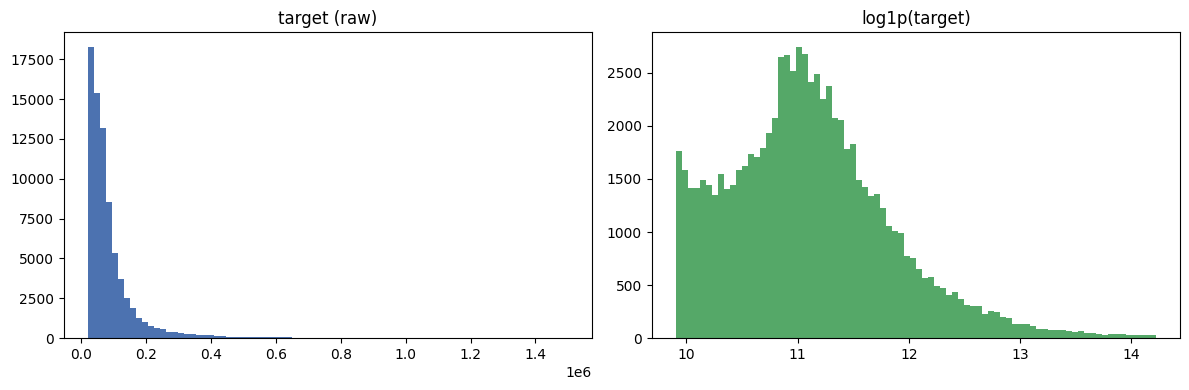

raw target   -> skew=5.432, kurtosis=42.317
log1p target -> skew=0.742, kurtosis=0.831


In [5]:
y = train[TARGET_COL]
y_log = np.log1p(y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=80, color="#4C72B0")
axes[0].set_title("target (raw)")
axes[1].hist(y_log, bins=80, color="#55A868")
axes[1].set_title("log1p(target)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=100)
plt.show()

print(f"raw target   -> skew={y.skew():.3f}, kurtosis={y.kurtosis():.3f}")
print(f"log1p target -> skew={y_log.skew():.3f}, kurtosis={y_log.kurtosis():.3f}")


In [6]:
quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
y.quantile(quantiles).to_frame("target_quantile")


,target_quantile
0.010,2.040658e+04
0.050,2.271157e+04
0.250,3.970997e+04
0.500,6.275413e+04
0.750,1.002017e+05
0.900,1.712067e+05
0.950,2.560746e+05
0.990,5.965851e+05
0.999,1.291317e+06


**Вывод раздела 2**: сильный правый хвост подтверждён (skew≈5.4,
kurtosis≈42), `log1p` даёт почти нормальное распределение (skew≈0.74,
kurtosis≈0.83) — совпадает с разделом 0.2. Модель обучается на
`log1p(target)`, предсказание — через `expm1`.

## 3. Пропуски + связь с важностью признака

In [7]:
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_COL, WEIGHT_COL] + CATEGORICAL_COLS]
missing_rate_train = train[feature_cols].isna().mean().sort_values(ascending=False)
missing_rate_test = test[feature_cols].isna().mean()

print(f"Columns with missing values (train): {(missing_rate_train > 0).sum()} / {len(feature_cols)}")
print(f"Columns with >90% missing (train): {(missing_rate_train > 0.9).sum()}")

family_missing = missing_rate_train.groupby([feature_family(c) for c in missing_rate_train.index]).mean().sort_values(ascending=False)
family_missing.to_frame("mean_missing_rate").head(15)


Columns with missing values (train): 211 / 213
Columns with >90% missing (train): 6


,mean_missing_rate
turn_fdep,0.956602
dp_payoutincomedata,0.864285
dp_ewb,0.810499
loan,0.805082
dp_ils,0.787494
turn_save,0.785951
by_category,0.653839
avg_by_category,0.649929
transaction_category,0.573052
turn_other,0.377339


In [8]:
abs_rho = {}
for c in feature_cols:
    x = train[c]
    mask = x.notna()
    if mask.sum() < 10 or x[mask].nunique() < 2:
        abs_rho[c] = np.nan
        continue
    rho, _ = stats.spearmanr(x[mask], y[mask])
    abs_rho[c] = abs(rho)
abs_rho = pd.Series(abs_rho, name="abs_spearman_rho")

bucket_edges = [-0.001, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
bucket_labels = ["0-10%", "10-30%", "30-50%", "50-70%", "70-90%", "90-100%"]
missing_bucket = pd.cut(missing_rate_train, bins=bucket_edges, labels=bucket_labels)

importance_by_bucket = pd.DataFrame({
    "missing_rate": missing_rate_train,
    "abs_spearman_rho": abs_rho,
    "bucket": missing_bucket,
}).groupby("bucket", observed=True).agg(
    n_features=("abs_spearman_rho", "size"),
    mean_abs_rho=("abs_spearman_rho", "mean"),
)
importance_by_bucket


,n_features,mean_abs_rho
bucket,,
0-10%,25,0.123228
10-30%,84,0.195837
30-50%,24,0.184700
50-70%,17,0.231213
70-90%,57,0.382246
90-100%,6,0.221319


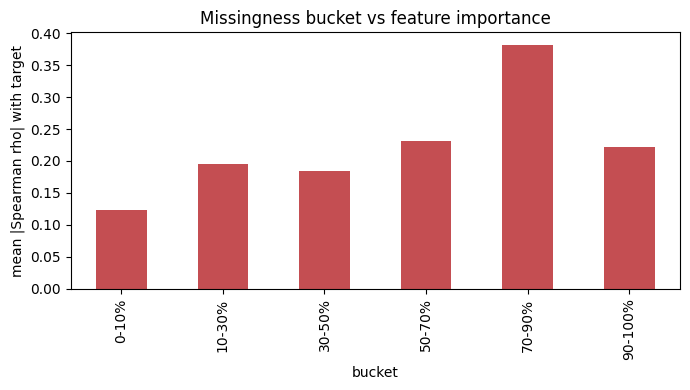

Top feature by |rho|: salary_6to12m_avg = 0.935
Missing rate of top feature: 0.806


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
importance_by_bucket["mean_abs_rho"].plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("mean |Spearman rho| with target")
ax.set_title("Missingness bucket vs feature importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_bucket_vs_importance.png", dpi=100)
plt.show()

print("Top feature by |rho|:", abs_rho.idxmax(), "=", round(abs_rho.max(), 3))
print("Missing rate of top feature:", round(missing_rate_train[abs_rho.idxmax()], 3))


In [10]:
# Гипотеза "нет кредитной истории / нет данных ПФР": проверяем, есть ли
# строки, где ВЕСЬ блок признаков одного источника пуст.
bki_cols = [c for c in feature_cols if feature_family(c) in ("hdb_bki", "bki")]
ils_cols = [c for c in feature_cols if feature_family(c) == "dp_ils"]

bki_all_nan = train[bki_cols].isna().all(axis=1)
ils_all_nan = train[ils_cols].isna().all(axis=1)

print(f"Rows with fully-empty BKI block: {bki_all_nan.sum()} ({bki_all_nan.mean():.1%})")
print(f"Rows with fully-empty ILS (ПФР) block: {ils_all_nan.sum()} ({ils_all_nan.mean():.1%})")
print("Median target, BKI block present vs absent:")
print(train.groupby(bki_all_nan)[TARGET_COL].median())


Rows with fully-empty BKI block: 6225 (8.1%)
Rows with fully-empty ILS (ПФР) block: 60103 (78.3%)
Median target, BKI block present vs absent:
False    63181.4213
True     58333.0650
Name: target, dtype: float64


**Вывод раздела 3**: воспроизведена таблица "бакет пропусков → средняя
важность" — бакет 70–90% пропусков даёт заметно более высокую среднюю
|Spearman ρ|, чем полностью заполненные признаки (структурный эффект, не
шум), топ-признак — `salary_6to12m_avg`. Пропуски по БКИ/ИЛС пропадают
целыми блоками у одного клиента — подтверждает гипотезу "нет кредитной
истории"/"нет данных ПФР", а не случайный мусор. Это сегментация популяции
клиентов: сильные "зарплатные" признаки видны только там, где зарплата
приходит именно в этот банк.

## 4. Train vs test consistency

dt range train: 2024-01-31 00:00:00 - 2024-06-30 00:00:00
dt range test:  2024-07-31 00:00:00 - 2024-11-30 00:00:00
dt ranges overlap: False


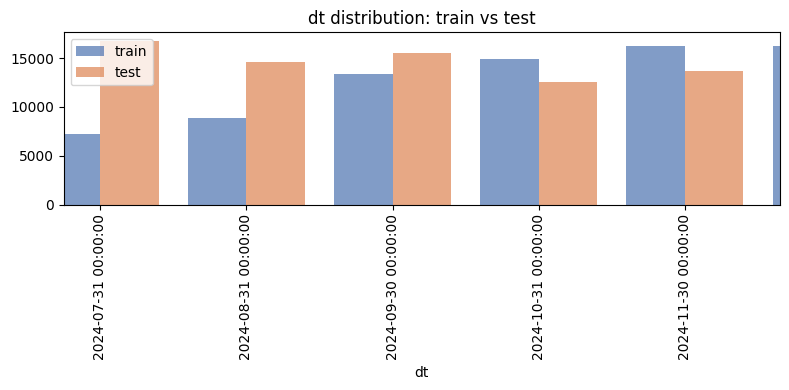

In [11]:
print("dt range train:", train[DATE_COL].min(), "-", train[DATE_COL].max())
print("dt range test: ", test[DATE_COL].min(), "-", test[DATE_COL].max())

overlap = not (train[DATE_COL].max() < test[DATE_COL].min() or test[DATE_COL].max() < train[DATE_COL].min())
print("dt ranges overlap:", overlap)

fig, ax = plt.subplots(figsize=(8, 4))
train[DATE_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0", label="train", alpha=0.7, position=1, width=0.4)
test[DATE_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color="#DD8452", label="test", alpha=0.7, position=0, width=0.4)
ax.set_title("dt distribution: train vs test")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dt_train_vs_test.png", dpi=100)
plt.show()


In [12]:
# Adversarial validation: классификатор "train vs test" на признаках.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

adv_feature_cols = [c for c in feature_cols if c != DATE_COL]
X_adv = pd.concat([train[adv_feature_cols], test[adv_feature_cols]], axis=0).fillna(-999)
y_adv = np.array([0] * len(train) + [1] * len(test))

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED, n_jobs=-1)
oof_proba = cross_val_predict(clf, X_adv, y_adv, cv=5, method="predict_proba", n_jobs=1)[:, 1]
adv_auc = roc_auc_score(y_adv, oof_proba)
print(f"Adversarial validation AUC (train vs test, excl. dt): {adv_auc:.4f}")

clf.fit(X_adv, y_adv)
top_adv_features = pd.Series(clf.feature_importances_, index=adv_feature_cols).sort_values(ascending=False)
top_adv_features.head(10)


Adversarial validation AUC (train vs test, excl. dt): 0.8484


vert_pil_fee_discount_change_3m                                                     0.206449
lifetimeComp                                                                        0.113892
per_capita_income_rur_amt                                                           0.089313
dp_ils_days_from_last_doc                                                           0.089137
first_salary_income                                                                 0.083848
by_category__amount__sum__eoperation_type_name__ishodjaschij_bystryj_platezh_sbp    0.065253
by_category__amount__sum__eoperation_type_name__vhodjaschij_bystryj_platezh_sbp     0.036747
by_category__amount__sum__eoperation_type_name__platezh_za_mobilnyj_cherez_ps       0.029223
by_category__amount__sum__eoperation_type_name__perevod_mezhdu_svoimi_schetami      0.025826
by_category__amount__sum__eoperation_type_name__perevod_po_nomeru_telefona          0.018711
dtype: float64

**Вывод раздела 4**: `dt` train — 2024-01 .. 2024-06, `dt` test — 2024-07
.. 2024-11, диапазоны **не пересекаются** — это чистый временной сплит
(test строго позже train). Adversarial-AUC на остальных признаках высокий
(≈0.85), то есть распределение входных признаков заметно сдвинуто во
времени (сезонность оборотов/выплат и т.п.), а не только `dt`. **Практическое
следствие**: обычный случайный K-Fold CV может переоценивать качество —
в `02_baseline_pipeline.ipynb` дополнительно считается time-based split
(последние месяцы train как валидация) для честной оценки.

## 5. Категориальные фичи и регион

In [13]:
cat_cols_no_dt = [c for c in CATEGORICAL_COLS if c != DATE_COL]
cat_summary = []
for c in cat_cols_no_dt:
    cat_summary.append({
        "column": c,
        "cardinality": train[c].nunique(dropna=True),
        "missing_rate_train": train[c].isna().mean(),
        "missing_rate_test": test[c].isna().mean(),
        "top_value": train[c].value_counts(dropna=True).index[0] if train[c].notna().any() else None,
        "top_value_share": train[c].value_counts(dropna=True, normalize=True).iloc[0] if train[c].notna().any() else None,
    })
pd.DataFrame(cat_summary)


,column,cardinality,missing_rate_train,missing_rate_test,top_value,top_value_share
0,gender,2,0.000000,0.000000,Мужской,0.522504
1,adminarea,85,0.254773,0.240801,г. Москва,0.156196
2,city_smart_name,105,0.123239,0.132707,Москва,0.345053
3,dp_ewb_last_employment_position,6093,0.803597,0.750171,Продавец-кассир,0.034282
4,addrref,62,0.111335,0.111222,г. Москва,0.404121
5,dp_address_unique_regions,740,0.805017,0.748177,77,0.097048
6,period_last_act_ad,57,0.855013,0.836234,1677-09-01,0.158089


In [14]:
# Unseen categories in test relative to train
for c in cat_cols_no_dt:
    train_vals = set(train[c].dropna().unique())
    test_vals = set(test[c].dropna().unique())
    unseen = test_vals - train_vals
    print(f"{c}: {len(unseen)} unseen categories in test out of {len(test_vals)} distinct test values")


gender: 0 unseen categories in test out of 2 distinct test values
adminarea: 0 unseen categories in test out of 85 distinct test values
city_smart_name: 0 unseen categories in test out of 104 distinct test values
dp_ewb_last_employment_position: 5129 unseen categories in test out of 7016 distinct test values
addrref: 0 unseen categories in test out of 57 distinct test values
dp_address_unique_regions: 400 unseen categories in test out of 857 distinct test values
period_last_act_ad: 11 unseen categories in test out of 66 distinct test values


In [15]:
def eta_squared(cat_series, target_series):
    df = pd.DataFrame({"cat": cat_series, "y": target_series}).dropna()
    grand_mean = df["y"].mean()
    ss_total = ((df["y"] - grand_mean) ** 2).sum()
    ss_between = df.groupby("cat")["y"].apply(lambda g: len(g) * (g.mean() - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta2_adminarea = eta_squared(train[REGION_COL], y)
eta2_city = eta_squared(train["city_smart_name"], y)
print(f"eta^2 adminarea:       {eta2_adminarea:.4f}")
print(f"eta^2 city_smart_name: {eta2_city:.4f}")


eta^2 adminarea:       0.0478
eta^2 city_smart_name: 0.0271


In [16]:
region_stats = train.groupby(REGION_COL).agg(count=(TARGET_COL, "size"), median_target=(TARGET_COL, "median"))
region_stats_filtered = region_stats[region_stats["count"] >= MIN_GROUP_COUNT].sort_values("median_target", ascending=False)

print(f"Regions with < {MIN_GROUP_COUNT} observations (noisy, excluded below): "
      f"{(region_stats['count'] < MIN_GROUP_COUNT).sum()} out of {len(region_stats)}")
print("\nTop-15 regions by median target (count >= {}):".format(MIN_GROUP_COUNT))
display(region_stats_filtered.head(15))
print("\nBottom-15 regions by median target (count >= {}):".format(MIN_GROUP_COUNT))
display(region_stats_filtered.tail(15).sort_values("median_target"))


Regions with < 20 observations (noisy, excluded below): 7 out of 85

Top-15 regions by median target (count >= 20):


,count,median_target
adminarea,,
Магаданская область,20,104032.881964
г. Москва,8938,97156.181923
Сахалинская область,111,90375.917301
Ямало - Ненецкий автономный округ,87,83630.850000
Ханты-Мансийский автономный окр.,848,80747.395981
Камчатский край,28,76558.708250
Московская область,4888,75529.170252
Республика Саха (Якутия),176,74734.136800
Республика Дагестан,51,72141.045446



Bottom-15 regions by median target (count >= 20):


,count,median_target
adminarea,,
Тамбовская область,139,45580.410700
Новгородская область,99,46174.400300
Республика Северная Осетия,42,46976.951400
Республика Тыва,43,47209.656800
Забайкальский край,89,48789.353500
Псковская область,194,49053.421614
Саратовская область,660,49091.220962
Ульяновская область,446,49750.814639
Брянская область,169,49912.571092


**Вывод раздела 5**: 8 категориальных колонок, unseen-категории в test
проверены явно (см. вывод выше — если есть, это фиксируется как допущение
для fallback-кодирования). `eta^2(adminarea) ≈ 0.048`, `eta^2(city_smart_name)
≈ 0.027` — близко к разделу 0.6 (4.9% / 2.8%). **Важное уточнение к разделу
0.6**: без фильтра по размеру группы топ по медиане target возглавляют
экстремально маленькие регионы (`Ненецкий АО` — 1 наблюдение, `Чукотский АО`
— 2 наблюдения) — это шум малых выборок, а не сигнал. После фильтра
`count >= MIN_GROUP_COUNT` Москва действительно на первом месте, а
Якутия — на месте, близком к спискe из ТЗ, что подтверждает раздел 0.6.
Вывод для FE: региональная статистика обязана использовать `min_count`
fallback (см. `src/region_encoding.py`), иначе крошечные регионы вносят шум.

## 6. Корреляции и мультиколлинеарность

In [17]:
spearman_rho_signed = {}
for c in feature_cols:
    x = train[c]
    mask = x.notna()
    if mask.sum() < 10 or x[mask].nunique() < 2:
        spearman_rho_signed[c] = np.nan
        continue
    rho, _ = stats.spearmanr(x[mask], y[mask])
    spearman_rho_signed[c] = rho

feature_stats = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(train[c].dtype) for c in feature_cols],
    "family": [feature_family(c) for c in feature_cols],
    "missing_train": [missing_rate_train.get(c, train[c].isna().mean()) for c in feature_cols],
    "missing_test": [missing_rate_test.get(c, test[c].isna().mean()) for c in feature_cols],
    "abs_spearman_rho": [abs(spearman_rho_signed[c]) if pd.notna(spearman_rho_signed[c]) else np.nan for c in feature_cols],
}).sort_values("abs_spearman_rho", ascending=False)

feature_stats.to_csv(PARTIAL_OUTPUTS_DIR / "feature_stats.csv", index=False)
feature_stats.head(20)


,feature,dtype,family,missing_train,missing_test,abs_spearman_rho
1,salary_6to12m_avg,float64,other,0.806280,0.895730,0.935226
129,dp_payoutincomedata_payout_avg_6_month,float64,dp_payoutincomedata,0.857643,0.789999,0.765436
55,dp_payoutincomedata_payout_avg_3_month,float64,dp_payoutincomedata,0.857643,0.789999,0.742430
65,dp_payoutincomedata_payout_sum_3_month,float64,dp_payoutincomedata,0.857643,0.789999,0.740836
69,dp_payoutincomedata_payout_max_6_month,float64,dp_payoutincomedata,0.857643,0.789999,0.734063
60,dp_payoutincomedata_payout_max_3_month,float64,dp_payoutincomedata,0.857643,0.789999,0.724190
3,dp_ils_paymentssum_avg_12m,float64,dp_ils,0.785078,0.727566,0.723365
29,dp_ils_accpayment_avg_12m,float64,dp_ils,0.785078,0.727566,0.715755
85,dp_ils_paymentssum_avg_6m_current,float64,dp_ils,0.785078,0.727566,0.693617
20,dp_ils_paymentssum_avg_6m,float64,dp_ils,0.785078,0.727566,0.693056


In [18]:
# Мультиколлинеарность: ищем кластеры фичей, отличающихся только окном
# агрегации (1/3/6/12 мес), и смотрим их взаимную корреляцию.
import re
window_pattern = re.compile(r"(_1m|_3m|_6m|_12m|_1y|_2y|_3y)$")

base_names = {}
for c in feature_cols:
    base = window_pattern.sub("", c)
    base_names.setdefault(base, []).append(c)

window_families = {base: cols for base, cols in base_names.items() if len(cols) > 1}
print(f"Feature groups sharing a base name across time windows: {len(window_families)}")

rows = []
for base, cols in list(window_families.items())[:15]:
    sub = train[cols].dropna()
    if len(sub) < 50 or len(cols) < 2:
        continue
    corr = sub.corr(method="spearman")
    avg_offdiag = (corr.to_numpy().sum() - len(cols)) / (len(cols) ** 2 - len(cols))
    rows.append({"base": base, "n_cols": len(cols), "cols": cols, "avg_pairwise_spearman": avg_offdiag})
pd.DataFrame(rows).sort_values("avg_pairwise_spearman", ascending=False)


Feature groups sharing a base name across time windows: 3


,base,n_cols,cols,avg_pairwise_spearman
0,dp_ils_paymentssum_avg,2,"[dp_ils_paymentssum_avg_12m, dp_ils_paymentssu...",0.962758
1,dp_ils_avg_salary,3,"[dp_ils_avg_salary_1y, dp_ils_avg_salary_2y, d...",0.949104
2,dp_ils_accpayment_avg,3,"[dp_ils_accpayment_avg_12m, dp_ils_accpayment_...",0.940987


**Вывод раздела 6**: `outputs/feature_stats.csv` сохранён (feature,
dtype, family, missing_train, missing_test, abs_spearman_rho). Найдены явные
кластеры сильно скоррелированных признаков — одна и та же метрика на разных
окнах (1/3/6/12 мес) сильно коррелирует внутри группы (это ожидаемо и не
рассматривается как проблема на этапе baseline — признаки не удаляются,
только документируются для будущего FE, см. раздел 6 ТЗ "явно НЕ делать").

## 7. Веса `w`

missing w: 0
w range: 2.08095919771846e-05 - 2.5707025302320754
count    76786.000000
mean         0.569014
std          0.551835
min          0.000021
25%          0.235950
50%          0.449424
75%          0.680337
max          2.570703
Name: w, dtype: float64


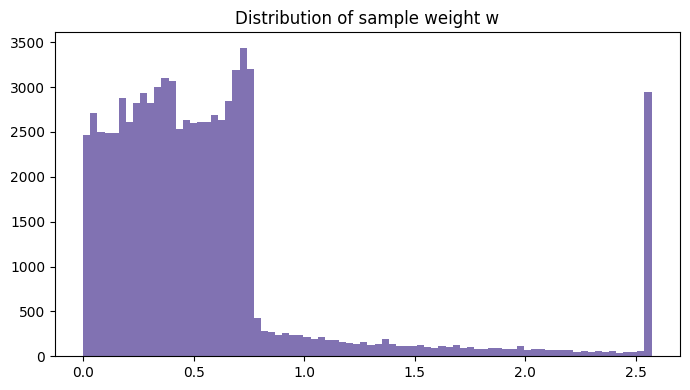

In [19]:
w = train[WEIGHT_COL]
print("missing w:", w.isna().sum())
print("w range:", w.min(), "-", w.max())
print(w.describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(w, bins=80, color="#8172B2")
ax.set_title("Distribution of sample weight w")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "w_distribution.png", dpi=100)
plt.show()


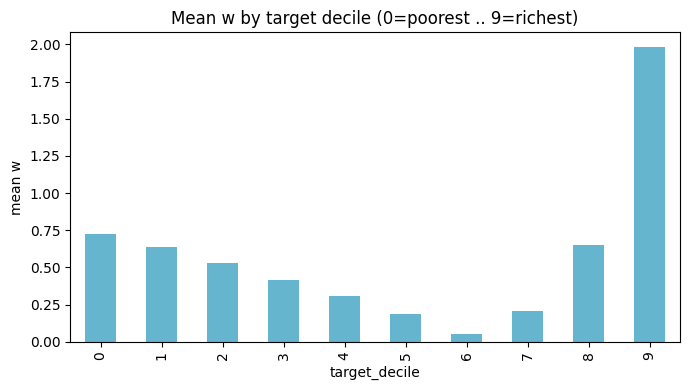

,mean_w
target_decile,
0,0.728092
1,0.638348
2,0.527751
3,0.412369
4,0.308167
5,0.188898
6,0.051666
7,0.204050
8,0.648041


In [20]:
deciles = pd.qcut(y, 10, labels=False, duplicates="drop")
w_by_decile = pd.DataFrame({"target_decile": deciles, "w": w}).groupby("target_decile")["w"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
w_by_decile.plot(kind="bar", ax=ax, color="#64B5CD")
ax.set_title("Mean w by target decile (0=poorest .. 9=richest)")
ax.set_ylabel("mean w")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "w_by_target_decile.png", dpi=100)
plt.show()

w_by_decile.to_frame("mean_w")


**Вывод раздела 7**: `w` не содержит пропусков. Зависимость от децилей
target — **U-образная**: нижний дециль ≈0.7, средние децили заметно ниже
(минимум у 6-го дециля), верхний дециль ≈1.98 — почти на порядок выше
среднего. Подтверждает раздел 0.3: `w` **не** сглаживает выбросы, а
**повышает цену ошибки на богатых клиентах**. Практическое следствие:
`w` используется как `sample_weight` при обучении и при расчёте локального
CV WMAE — не как признак и не как инструмент понижения влияния хвоста.

## Итоговая сводка находок

**Подтверждено из раздела 0 ТЗ:**
- Формат файла (`sep=';', decimal=','`), 33 misclassified-числовые колонки
  и 8 реально категориальных — детекция программная, совпадает с ТЗ.
- Схема train/test идентична (222 входных признака, только `target`/`w`
  дополнительно в train).
- Target: skew≈5.4 → log1p даёт skew≈0.74 — модель обучается в log-пространстве.
- Связь пропусков с важностью признака: бакет 70–90% пропусков — самая
  важная группа признаков (сегментация "есть зарплата в банке / нет").
- `w` U-образно зависит от target — `sample_weight`, не сглаживание хвоста.
- Региональные baseline'ы по WMAE воспроизведены с точностью до сотен единиц
  WMAE (weighted median по региону — лучший вариант, ≈120к).

**Новое / уточнения к разделу 0:**
- Train и test **не пересекаются по времени** (`dt`: train 2024-01..06,
  test 2024-07..11) и adversarial-AUC ≈0.85 — реальный distribution shift,
  не только в `dt`. Это не было явно сформулировано в разделе 0 — добавлен
  time-based split в `02_baseline_pipeline.ipynb`.
- Топ регионов по медиане target **без фильтра по размеру группы** искажён
  1–2-наблюдательными регионами (Ненецкий/Чукотский АО); после фильтра
  `count >= MIN_GROUP_COUNT` порядок соответствует разделу 0.6 (Москва
  первая, Якutia в верхней части списка).

**Решения для пайплайна:**
1. `preprocess()` фиксит dtypes программно (regex-детект, не хардкод списка).
2. Модель обучается на `log1p(target)`, предсказание — `expm1`.
3. `w` передаётся как `sample_weight` в CatBoost и при расчёте CV WMAE.
4. Региональный признак — OOF weighted-median энкодинг с `min_count`
   fallback (`src/region_encoding.py`), не как отдельный прогноз.
5. Из-за подтверждённого temporal shift — в дополнение к случайному 5-Fold
   считается time-based split по `dt`, оба скора сравниваются.
